# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

Actividad de Semana 3 - Septiembre 2024

**Rotación de Personal - IBM**

#### **Nombre y matrícula: José Florencio Maguey Peralta A01796727 **

#### **La siguiente actividad se basa en los datos del archivo "WA_Fn-UseC_-HR-Employee-Attrition.csv" que se encuentra en la siguiente liga de Kaggle, llamada "IBM HR Analytics Employee Attrition & Performance":**

https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
# Incluye aquí todas las librerías que consideres necesarias:

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer ##creo que este no lo ocupé
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler, RobustScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, classification_report



# **Ejercicio 1:**

#### **Incluye una breve introducción sobre lo que se entiende por el problema de rotación de personal en las organizaciones (employee attrition problem).**

++++++++ Inicia la sección de agregar texto: ++++++++++++


La rotación de personal es un KPI que utlizan las empresas para tener medido cuántas personas salen de la empresa en un periodo determinado. El KPI se obtinie dividiendo las personas que abandonan entre las que entraron, en ambas es el mismo periodo; el cociente obtenido se multiplica por 100%.

De acuerdo con varios esudios, algunas de las causas para esta rotación son el ambiente de trabajo, burout, falta de sentido y motivación, mal jefe, aburrimiento, falta de formación.

++++++++ Termina la sección de agregar texto. +++++++++++

# **Ejercicio 2:**

#### **Carga los datos del archivo de la página de Kaggle indicada como un DataFrame de Pandas, llamado "df" y utilicemos el método “describe” con el argumento include= “all”, para obtener una primera descripción general de cada variable.**

In [49]:
# ++++++++++++++ Inicia sección de agregar código ++++++++++++++++++++

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI & ML/WA_Fn-UseC_-HR-Employee-Attrition.csv", sep=",")


# +++++++++++++ Termina sección de agregar código +++++++++++++++++++++


print("Tamaño del DataFrame:", df.shape)
df.describe(include = 'all').T


Tamaño del DataFrame: (1470, 35)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


# **Ejercicio 3:**

#### **Indica cuál es la diferencia entre utilizar o no el argumento include=”all” del método "describe" en el ejercicio anterior.**

++++++++ Inicia la sección de agregar texto: ++++++++++++


Se incluyen todas la columnas del dataframe, es decir, las numericas y las de texto.


++++++++ Termina la sección de agregar texto. +++++++++++

# **Ejercicio 4:**

#### **Con base a la información desplegada por la instrucción anterior, hemos decidido cancelar los siguientes factores de nuestro problema: Over18, EmployeeCount, StandardHours, EmployeeNumber. Explica cuál es la justificación que nos permite cancelar cada uno de estos factores:**

++++++++ Inicia la sección de agregar texto: ++++++++++++

**a)   Over18**: data tipo booleano, por lo tanto, no cobra relevancia.

**b)	EmployeeCount**: todos las tuplas tienen el valor de 1

**c)	StandardHours**: todas las tuplas tienen 80

**d)	EmployeeNumber**: es un dato informativo sobre el número de empleado

++++++++ Termina la sección de agregar texto. +++++++++++




In [50]:
# Eliminamos los factores indicados:

df = df.drop(['Over18','EmployeeCount','StandardHours','EmployeeNumber'],axis=1)

print("Tamaño del nuevo DataFrame:", df.shape)

Tamaño del nuevo DataFrame: (1470, 31)


# **Ejercicio 5:**

#### **Realiza una partición de los datos en Entrenamiento, Validación y Prueba, del 70%, 15% y 15%, respectivamente. Llama a dichos conjuntos Xtrain, Xval, Xtest, ytrain, yval, ytest, para los datos de entrada y de salida, respectivamente. Asegúrate que dicha partición conserve la estratificación de las clases de la variable “Attrition”. Despliega además la dimensión obtenida de los tres conjuntos: Entrenamiento, Validación y Prueba.**

#### **NOTA: Utiliza semillas en cada función de partición, para permitir la repetibilidad de tu modelo y poder evaluarlo de mejor majera.**

In [51]:
# ++++++++++++++ Inicia sección de agregar código +++++++++++++++++++++

x=df.drop(['Attrition'],axis=1)
y=df[['Attrition']]

##las variables xvt y yvt es en donde se guarda el remanente del dataframe (30%)
X_train, Xvt, y_train, yvt = train_test_split(x,      # Variables de entrada.
                                              y,      # variable de salida.
                                              train_size=0.7,  # Puedes indicar el tamaño o proporción del conjunto "train" o del "test".
                                              random_state=1,  # Asignamos una semilla para garantizar la repetibilidad de los resultados.
                                              stratify=y
                                              )

##las variables X_val y X_test es en donde se guarda el remanente del dataframe (15%)
X_val, X_test, y_val, y_test = train_test_split(Xvt, yvt, test_size=0.5,  random_state=3, stratify=yvt)



# ++++++++++++++ Termina sección de agregar código +++++++++++++++++++++

# **Ejercicio 6:**


#### **Aplica la transformación LabelEncoder() de sklearn a la variable de salida “Attrition”. Las nuevas variables deberán llamarse ahora: ytrainT, yvalT, ytestT. Encuentra la proporción de datos en cada nivel de esta variable y con base a dicha información indica si podemos considerar que tenemos un problema de datos desbalanceados.**

#### NOTA: Aplica esta transformación evitando el filtrado de información (data leakage).

In [52]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


ytrainT, yvalT, ytestT=LabelEncoder().fit_transform(y_train), LabelEncoder().fit_transform(y_val), LabelEncoder().fit_transform(y_test)

ytrainT = pd.Series(ytrainT)
yvalT = pd.Series(yvalT)
ytestT = pd.Series(ytestT)

# +++++++++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

print("Porcentaje de datos en cada clase de entrenamiento - Attrition:")
print(ytrainT.value_counts() / ytrainT.shape[0])

print("Porcentaje de datos en cada clase de validación - Attrition:")
print(yvalT.value_counts() / yvalT.shape[0])

print("Porcentaje de datos en cada clase de testeo - Attrition:")
print(ytestT.value_counts() / ytestT.shape[0])

Porcentaje de datos en cada clase de entrenamiento - Attrition:
0    0.838678
1    0.161322
Name: count, dtype: float64
Porcentaje de datos en cada clase de validación - Attrition:
0    0.840909
1    0.159091
Name: count, dtype: float64
Porcentaje de datos en cada clase de testeo - Attrition:
0    0.837104
1    0.162896
Name: count, dtype: float64


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Si existe un desbalanceo, ya que podemos observar que se tiene más de un 80% de un lado, mientras que en el otro se tiene un máximo de un 16%.

Con relación a un problema en data leakage, por lo que entiendo, no se tiene para los datos debido a que esta definido el parámetro random_state; lo anterior garantiza que en cada ejecución se pueda tener repetibilidad con los resultados obtenidos.

# **Ejercicio 7:**


#### **Incluye a continuación el análisis gáfico y describtivo que consideres adecuado. Con base a estos gráficos ¿qué tipo de transformaciones sugieres llevar a cabo en dichas variables?**

<ipython-input-53-87074ee47fc5>:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)  # Ajuste de tamaño y rotación de etiquetas
<ipython-input-53-87074ee47fc5>:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)  # Ajuste de tamaño y rotación de etiquetas
<ipython-input-53-87074ee47fc5>:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)  # Ajuste de tamaño y rotación de etiquetas
<ipython-input-53-87074ee47fc5>:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks

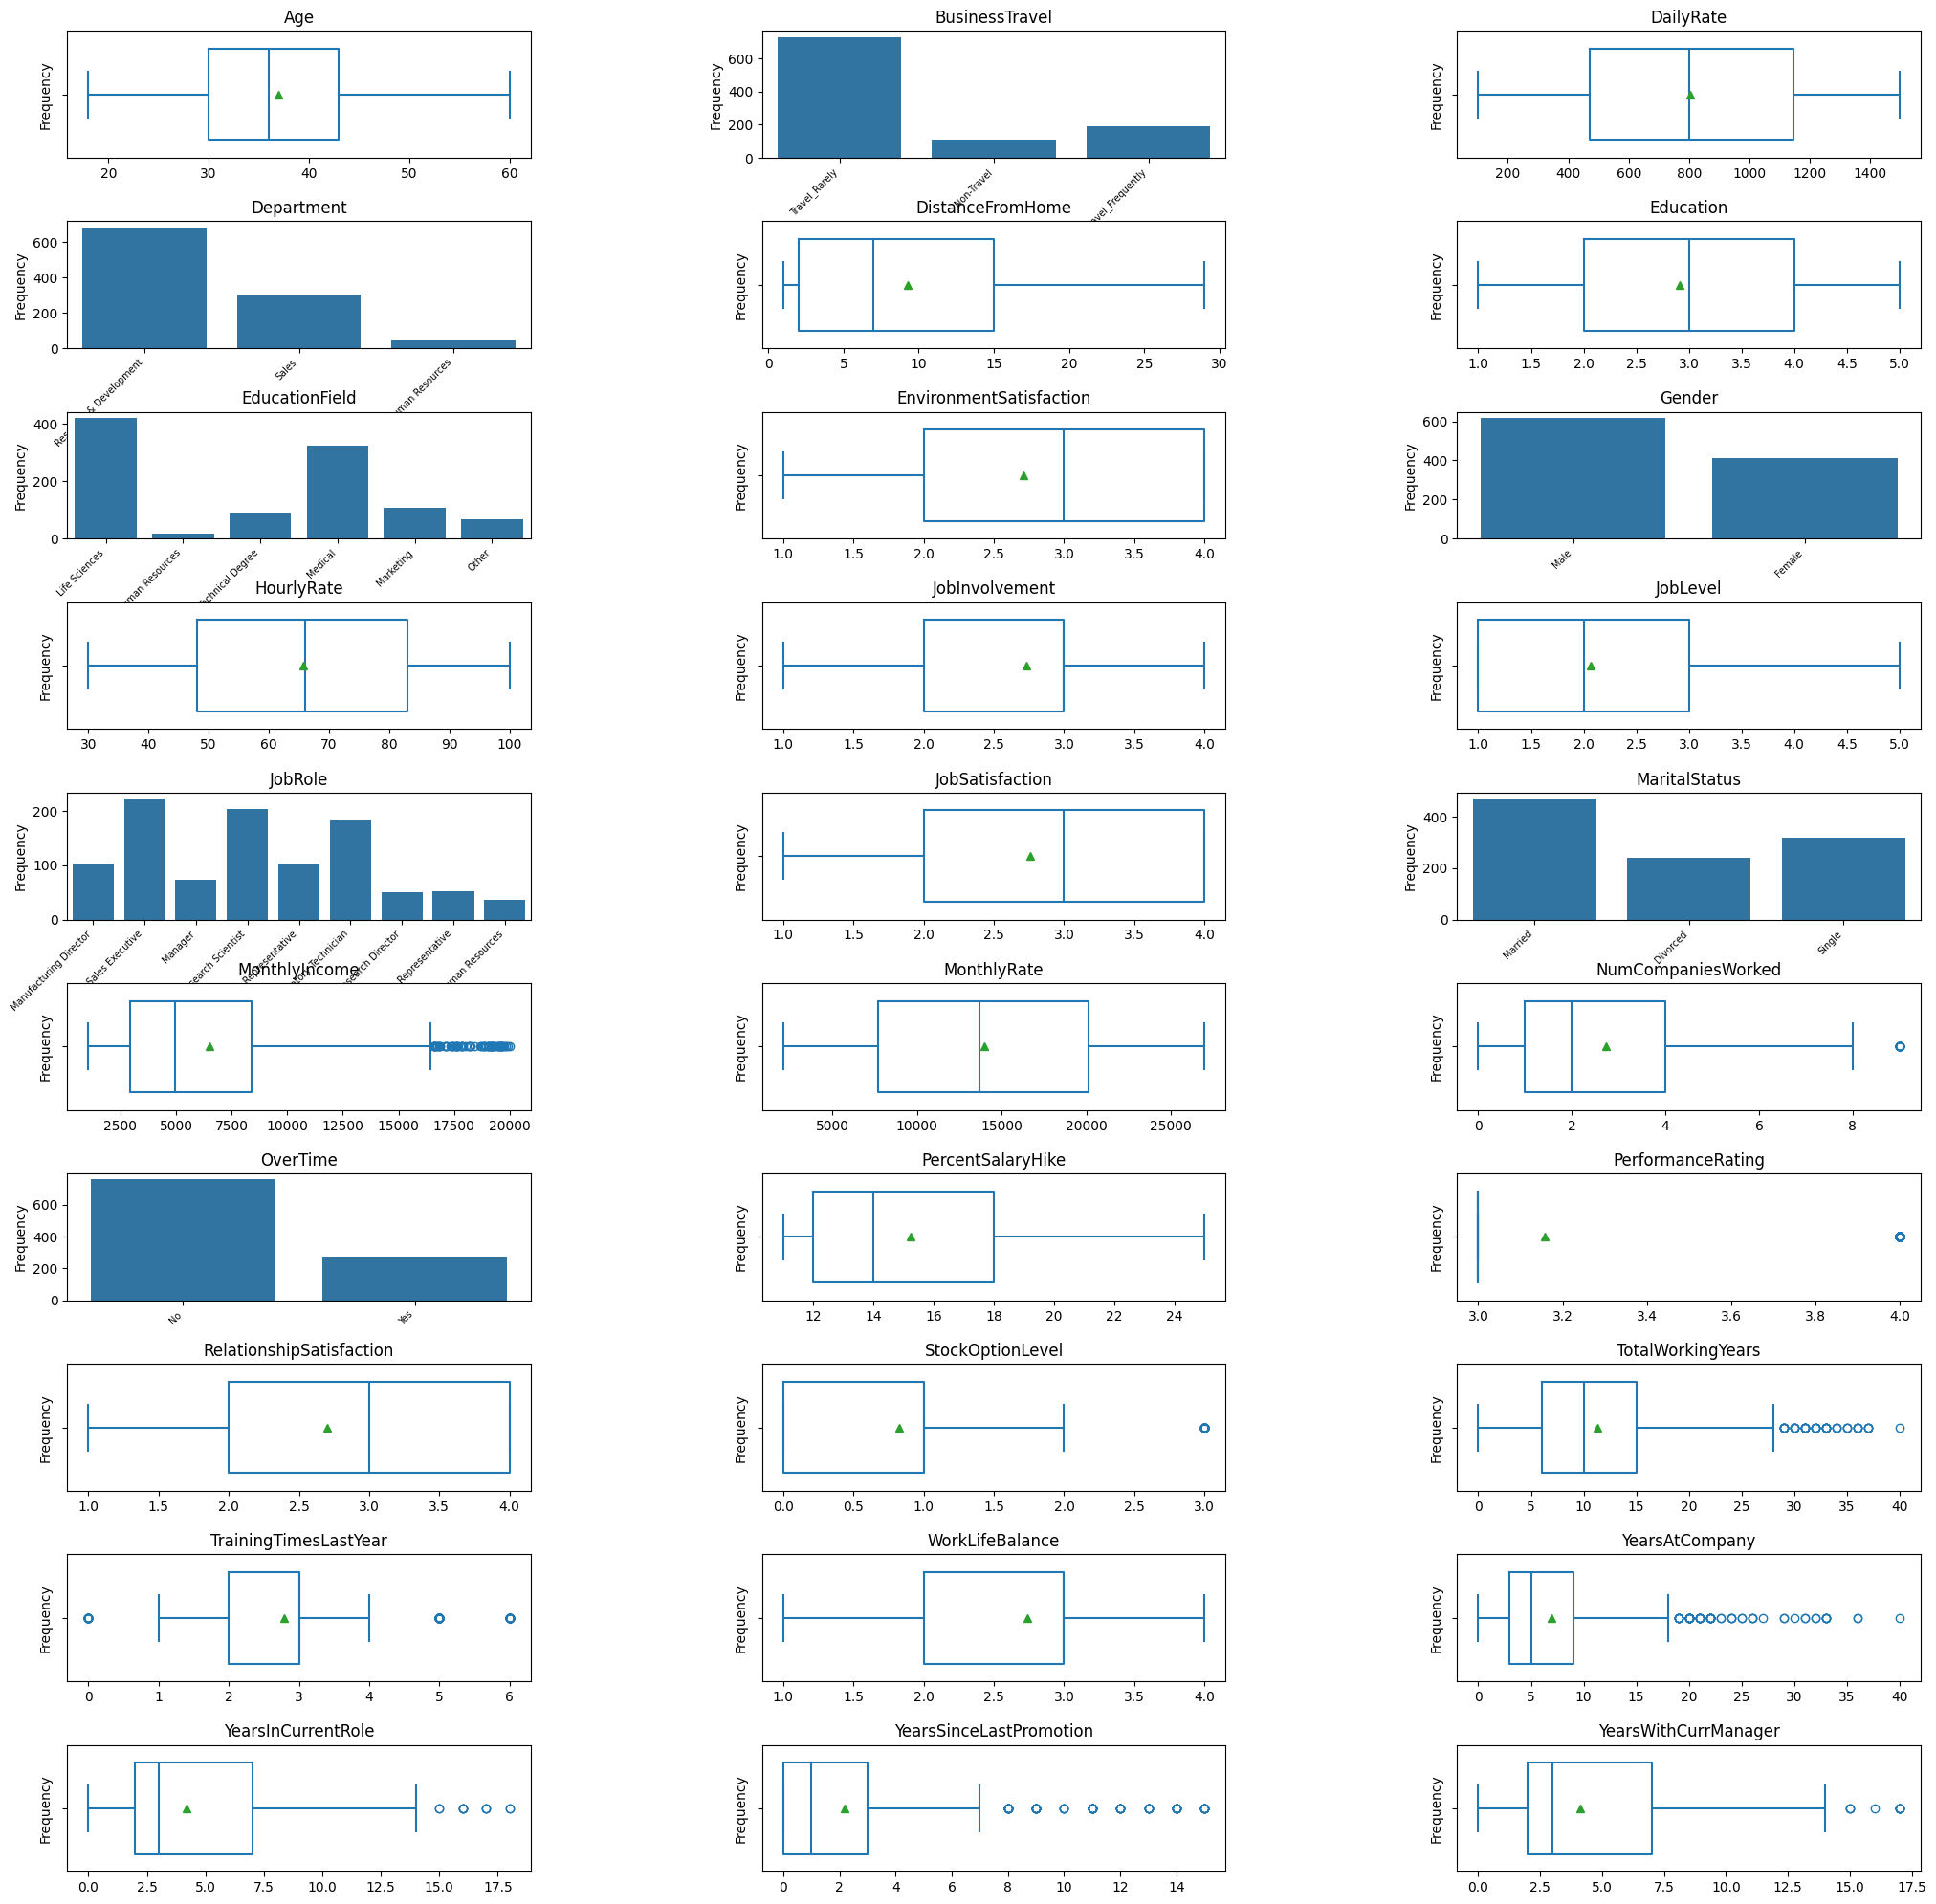

In [53]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
# Incluye en esta sección todas las celdas que consideres conveniente.

cols_cat = X_train.select_dtypes(include='object').columns
cols_num = X_train.select_dtypes(include='number').columns


fig, axes = plt.subplots(10, 3, figsize=(25, 25))
plt.subplots_adjust(wspace=0.5, hspace=0.5)
axes = axes.ravel()


for col, ax in zip(X_train.columns, axes):
    if col in cols_cat:
        sns.countplot(data=X_train, x=col, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)  # Ajuste de tamaño y rotación de etiquetas
    else:
        sns.boxplot(data=X_train,x=col, ax=ax, showmeans=True, gap=.1, fill=False)
        ax.set(title=f'{col}', xlabel=None)

    # Configuración del título y etiquetas de los ejes
    ax.set(title=f'{col}', xlabel=None, ylabel='Frequency')



# Mostrar la figura completa
plt.show()


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++



Considero que las variables más relevantes son las que tiene putliers, lo anterior debido al impacto que tienen al momento de hacer una regresión, para las variables con estas características considero que lo mejor es escalarlas mediante el RobustScaler ya que su principal función es minimizar el impacto de los outliers.

Para las variables que tienen un sesgo positivo o negativo, lo que considero es escalar con un StandardScaler para corregir el sesgo.

# **Ejercicio 8:**

#### **Utiliza las clases Pipeline y ColumnTransformer de Sklearn para definir las transformaciones que deberán aplicarse a cada variable de acuerdo a su tipo.**



In [54]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


# NUMÉRICAS:
numericas_pipeline = Pipeline([
                                 ('Num_Scaler', RobustScaler())
                              ])
numericas_pipeline_nombres = ['NumCompaniesWorked',
                              'TrainingTimesLastYear',
                              'Age',
                              'DailyRate',
                              'DistanceFromHome',
                              'HourlyRate',
                              'MonthlyIncome',
                              'MonthlyRate',
                              'PercentSalaryHike',
                              'TotalWorkingYears',
                              'YearsAtCompany',
                              'YearsInCurrentRole',
                              'YearsSinceLastPromotion',
                              'YearsWithCurrManager']

# ORDINALES:
catOrd_pipeline = Pipeline([
                               ('Ord_Scaler', StandardScaler()),
                               ('Ord_Encoder', OrdinalEncoder())
                            ])
catOrd_pipeline_nombres = ['Education',
                           'EnvironmentSatisfaction',
                           'JobInvolvement',
                           'JobLevel',
                           'JobSatisfaction',
                           'PerformanceRating',
                           'RelationshipSatisfaction',
                           'StockOptionLevel',
                           'WorkLifeBalance']

# BINARIAS:
catBin_pipeline = Pipeline(steps=[
                                     ('OneHotE', OneHotEncoder(handle_unknown='ignore', drop='first'))
                                   ])
catBin_pipeline_nombres = ['Gender', 'OverTime']

# NOMINALES:
catNom_pipeline = Pipeline(steps=[
                                     ('OHE_Nominales', OneHotEncoder(handle_unknown='ignore', drop='first'))
                                  ])
catNom_pipeline_nombres = ['BusinessTravel',
                           'Department',
                           'EducationField',
                           'JobRole',
                           'MaritalStatus']

columnasTransformer = ColumnTransformer(transformers=[('numpipe', numericas_pipeline, numericas_pipeline_nombres),
                                                      ('catord', catOrd_pipeline, catOrd_pipeline_nombres),
                                                      ('catbin', catBin_pipeline, catBin_pipeline_nombres),
                                                      ('catnom', catNom_pipeline, catNom_pipeline_nombres)],
                                        remainder='passthrough')


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

# **Ejercicio 9:**

#### **Reagrupa los conjuntos de entrenamiento y validación en un solo DataFrame.**

#### **A estos nuevos DataFrame llamarlos Xtv y ytv.**

In [55]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

#s´+olo es un concat
Xtv=pd.concat([X_train,X_val])
ytv=pd.concat([ytrainT,yvalT])


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

print(Xtv.shape)
print(ytv.shape)

(1249, 30)
(1249,)


# **Ejercicio 10:**

#### **Busca los mejores hiperparámetros.**

>> LR 0.871 (0.012)
>> LASSO 0.878 (0.012)
>> RIDGE 0.876 (0.011)
>> EN 0.877 (0.011)
>> kNN 0.834 (0.012)


<ipython-input-56-e54e0a9436dc>:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados, labels=nombres, showmeans=True)   # gráficos de caja para una comparación visual de los resultados.


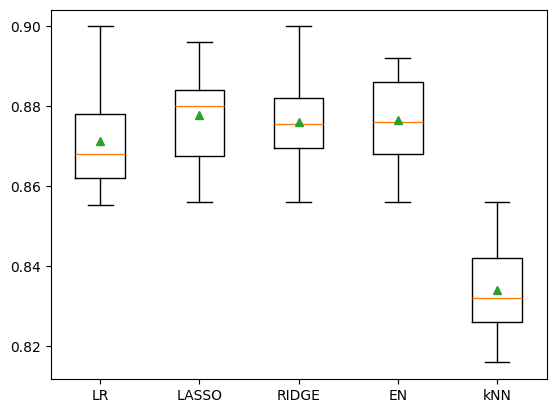

In [56]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


def mis_modelos():
  modelos, nombres = list(), list()

  # LR - Regresión Logística sin regularización:
  modelos.append(LogisticRegression(penalty=None,  # Este valor de "penalty" no se debe de cambiar, ya que define el modelo sin regularización.
                                    solver='lbfgs', max_iter=2000, warm_start=True, C=1,     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    random_state=1))
  nombres.append('LR')


  # Lasso - Regresión Logística con regularización L1:
  modelos.append(LogisticRegression(penalty='l1',
                                    solver='liblinear', max_iter=2000,  warm_start=True, C=1,    # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    random_state=1))
  nombres.append('LASSO')


  # Ridge - Regresión Logística con regularización L2:
  modelos.append(LogisticRegression(penalty='l2',
                                    solver='saga', max_iter=2000, warm_start=True, C=1,    # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    random_state=1))
  nombres.append('RIDGE')


  # Elastic_Net - - Regresión Logística con regularización L1 y L2:
  modelos.append(LogisticRegression(penalty='elasticnet',
                                    solver='saga', max_iter=2000,  warm_start=True, C=1, l1_ratio=0.5,    # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    random_state=1))
  nombres.append('EN')



  # kNN - k-Vecinos más cercanos:
  modelos.append(KNeighborsClassifier(n_neighbors=3)) # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
  nombres.append('kNN')

  return modelos, nombres

# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++



# Entrenamos los modelos:

modelos, nombres = mis_modelos()  # accesando los modelos.
resultados = list()    # para guardar los resultados en esta lista.

# Iterando y entrenando sobre cada modelo:
for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])   # Transformaciones y modelo en un Pipeline.

  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)     # Aplicando una de las variantes de Validación Cruzada.

  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv1)   # entrenando y generando los resultados.

  resultados.append(scores)    # guardando los resultados en la lista.
  print('>> %s %.3f (%.3f)' % (nombres[i], np.nanmean(scores), np.nanstd(scores)))  # desplegando los promedios de cada modelo.


plt.boxplot(resultados, labels=nombres, showmeans=True)   # gráficos de caja para una comparación visual de los resultados.
plt.show()

# **Ejercicio 11:**

#### **Utilizando el mejor modelo y los datos Xtv, ytv, realiza una búsqueda de malla para encontrar los mejores hiperparámetros. Verifica que el modelo no esté subentrenado o sobreentrenado.**



In [57]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

# Lasso - Regresión Logística con regularización L1:
mejor_modelo = LogisticRegression(penalty='l1',
                                  warm_start=True,    # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                  random_state=1)

dicc_grid = {'C':[ 0.001,0.25,0.5,0.75, 0.8,0.85,0.88,0.9,0.95,0.98,1],
             'solver':['liblinear','saga'],
             'max_iter':[3000]
             }

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=8)

grid = GridSearchCV(estimator=mejor_modelo,
                    param_grid=dicc_grid,
                    cv=cv,
                    scoring='accuracy',  # podemos seleccionar otras métricas: 'accuracy', 'f1', 'precision', 'recall'
                    n_jobs=-1,
                    return_train_score=True    # podemos obtener los de entrenamiento para verificar sobreentrenamiento.
                    )


Xx = columnasTransformer.fit_transform(Xtv)

grid_result = grid.fit(Xx, np.ravel(ytv))

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++



print("Mejor modelo: %f usando %s" % (grid_result.best_score_, grid_result.best_params_))
print('Promedios Train mean(std): %.4f(%.4f)' % (np.nanmean(grid_result.cv_results_['mean_train_score']),
                                                 np.nanmean(grid_result.cv_results_['std_train_score'])))
print('Promedios Val mean(std): %.4f(%.4f)' % (grid_result.cv_results_['mean_test_score'].mean(),
                                               grid_result.cv_results_['std_test_score'].mean()))


Mejor modelo: 0.879512 usando {'C': 0.8, 'max_iter': 3000, 'solver': 'liblinear'}
Promedios Train mean(std): 0.8897(0.0045)
Promedios Val mean(std): 0.8750(0.0144)


# **Ejercicio 12:**

#### **Con los mejores valores de hiperparámetros del mejor modelo encontrado, obtener:**

*   #### **a) Matriz de Confusión.**
*   #### **b) Análisis de Imprtancia de Factores.**
*   #### **c) Reporte de métricas.**

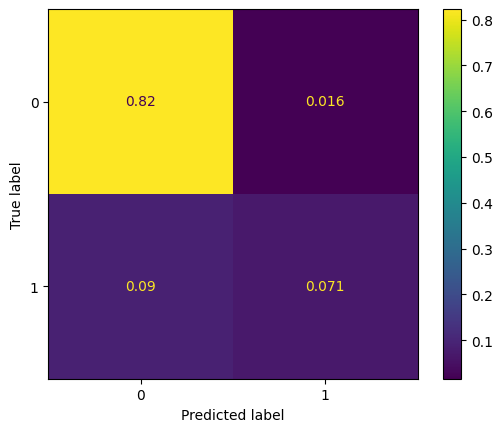



--------------------Análisis de Importancia de Factores:--------------------
                                            Importancia
numpipe__NumCompaniesWorked                   0.575218
numpipe__TrainingTimesLastYear               -0.174753
numpipe__Age                                 -0.389098
numpipe__DailyRate                           -0.117599
numpipe__DistanceFromHome                     0.480999
numpipe__HourlyRate                           0.120830
numpipe__MonthlyIncome                        0.000000
numpipe__MonthlyRate                          0.182775
numpipe__PercentSalaryHike                   -0.087823
numpipe__TotalWorkingYears                   -0.322383
numpipe__YearsAtCompany                       0.350998
numpipe__YearsInCurrentRole                  -0.567124
numpipe__YearsSinceLastPromotion              0.417359
numpipe__YearsWithCurrManager                -0.469475
catord__Education                             0.025742
catord__EnvironmentSatisfaction         

In [58]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++
# Incluye todas las celdas que consideres adecuado para responder
# estos tres incisos del ejercicio.

# Mejor modelo e hiperparámetros:
modelo_mejor = LogisticRegression(penalty='l1',
                                  max_iter=3000,
                                  solver='liblinear',
                                  C=0.8,
                                  random_state=1,
                                  warm_start=True)

Xx = columnasTransformer.fit_transform(Xtv)

mejor_result = modelo_mejor.fit(Xx, np.ravel(ytv))

#A) Matriz de confusión
ConfusionMatrixDisplay.from_estimator(mejor_result, Xx, np.ravel(ytv), normalize='all')
plt.show()

#B) Análisis de Importancia de Factores
importancia_factores = pd.DataFrame(data=mejor_result.coef_.reshape(-1,1),
                                    index=columnasTransformer.get_feature_names_out(),
                                    columns=['Importancia'])
print("\n\n--------------------Análisis de Importancia de Factores:--------------------\n", importancia_factores)

#C) Reporte de métricas
y_pred = modelo_mejor.predict(Xx)
report = classification_report(ytv, y_pred)
print("\n\n--------------------Reporte de métricas:--------------------\n", report)
# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++

# **Ejercicio 13**

#### **Obtener el desempeño final del modelo (accuracy) con el conjunto de prueba (test).**

In [59]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

XT_transfomed=columnasTransformer.transform(X_test)

# Crear el LabelEncoder
label_encoder = LabelEncoder()

# Ajustar el LabelEncoder y transformar y_test
y_test_encoded = label_encoder.fit_transform(y_test)

# Transformar las predicciones a etiquetas originales
y_pred_encoded = grid.best_estimator_.predict(XT_transfomed)

# Obtener el puntaje de precisión
test_score = grid.best_estimator_.score(XT_transfomed, y_test_encoded)
print("Accuracy en el conjunto de testeo:", test_score)


# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++

Accuracy en el conjunto de prueba: 0.8868778280542986


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# **Ejercicio 14**

#### **Incluye tus conclusiones finales de la actividad.**

#### +++++++++ Inicia sección para incluir tus conclusiones ++++++++++++++++++++++++

Tomando en consideración que la pregunta de negocio es si los empleados van a renunciar o no, y considerando que el accuracy con los datos de entrenamiento y validación era del 89% y con los datos de testeo es del 88%, considero que el modelo predice de manera correcta, pues la diferencia entre uno y otro es del 1%.

Con realción a si los empleados renuncian y de acuerdo con la matriz de confusión de los datos de entrenamiento y validación es que la mayoría se encuentra en un verdadero negativo, yo considero qu eno renunciarían.

Por úlitmo, temanre técnica, la actividad me ayuda a aterrizar un poco más el conocimiento de cómo se estructura un código de ML.

#### +++++++++ Termina sección para incluir tus conclusiones ++++++++++++++++++++++++

# >> **Fin de la Actividad de la Semana 3** <<